In [1]:
import alphapepttools as apt
import anndata as ad
import decoupler as dc
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mudata as md
import muon
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from alphabase.pg_reader.keys import PGCols
from sklearn.metrics import silhouette_score

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
# Mirror the central alphapepttools plot settings (defaults.PlotSettings) onto matplotlib's
# global rcParams so notebook figures match the library defaults.
from alphapepttools.pl import defaults

_plot_config = defaults.plot_settings.to_dict()
plt.rcParams.update(
    {
        "font.size": _plot_config["font_sizes"]["medium"],
        "axes.titlesize": _plot_config["axes"]["title_size"],
        "axes.labelsize": _plot_config["axes"]["label_size"],
        "xtick.labelsize": _plot_config["axes"]["tick_size"],
        "ytick.labelsize": _plot_config["axes"]["tick_size"],
        "legend.fontsize": _plot_config["legend"]["font_size"],
        "legend.title_fontsize": _plot_config["legend"]["title_size"],
        "lines.linewidth": _plot_config["linewidths"]["medium"],
        "lines.markersize": _plot_config["marker_sizes"]["medium"],
        "figure.dpi": _plot_config["resolution"]["dpi"],
        "savefig.dpi": _plot_config["resolution"]["dpi"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

In [3]:
mdata = md.read_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/sit

In [15]:
# Shared color scheme for the omics modalities, reused across loading and enrichment plots
palette = {"proteins": "#9ED8CB", "rna": "#BDCEE5", "methylation": "#D5BDDE"}


def plot_modality_loadings(
    data: pd.DataFrame,
    *,
    score: str,
    feature: str,
    palette: dict,
    modality_column: str = "modality",
    xlabel: str = "Score",
    ax: plt.Axes | None = None,
    fontsize: int = 5,
    legend: bool = True
) -> plt.Axes:
    """Horizontal bar plot of per-feature scores, colored by omics modality.

    Used to display either MOFA+ factor loadings or gene set enrichment scores. Each
    bar corresponds to a single feature (a gene or a pathway) and is colored by the
    modality it originates from.

    Parameters
    ----------
    data
        Long-format dataframe with one row per feature.
    score
        Column holding the numeric value drawn as bar length (x-axis).
    feature
        Column holding the feature labels shown on the y-axis.
    palette
        Mapping of modality name to color.
    modality_column
        Column holding the modality of each feature.
    xlabel
        Label of the x-axis.
    ax
        Axes to draw on. If `None`, a new figure and axes are created.

    Notes
    -----
    Feature labels that occur more than once in `data` (e.g. a pathway or gene shared
    across modalities) are rendered in bold to highlight cross-modal agreement.
    """
    data = data.sort_values(by=score)
    colors = data[modality_column].map(palette)

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 8))

    ax.barh(range(len(data)), data[score], color=colors)
    ax.set_yticks(range(len(data)))
    labels = ax.set_yticklabels(data[feature], fontsize=fontsize)

    # Highlight features that occur in more than one row (e.g. shared across modalities)
    feature_counts = data[feature].value_counts()
    for label, name in zip(labels, data[feature], strict=True):
        if feature_counts[name] > 1:
            label.set_fontweight("bold")
    ax.axvline(0, color="black", linewidth=0.8)  # zero reference line
    ax.set_xlabel(xlabel, labelpad=0)

    # Legend mapping each color back to its modality
    if legend:
        handles = [
            mpatches.Patch(color=color, label=modality)
            for modality, color in palette.items()
        ]
        ax.legend(
            handles=handles, title="Modality", bbox_to_anchor=(1.01, 1), loc="upper left"
        )

    ax.spines[["top", "right"]].set_visible(False)
    return ax

In [5]:
mofa_loadings = pd.DataFrame(
    mdata.varm["LFs"], index=pd.MultiIndex.from_frame(mdata.var.reset_index(names="genes")[["genes", "modality"]])
)

mofa_loadings

,,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
genes,modality,,,,,,,,,,,,,,,,,,,,,
A1BG,proteins,0.172913,-0.026706,-0.002021,-0.098686,0.001982,0.000210,-0.012240,-0.144932,-0.014722,0.000722,...,0.681463,-0.175271,0.038054,-0.040847,-1.087811,0.005504,0.025088,0.007520,-0.050735,0.003166
A2M,proteins,0.340784,-0.023044,0.035473,-0.272198,0.010998,0.001424,0.002820,-0.002830,-0.016485,-0.001102,...,0.891250,0.042361,0.016262,-0.066233,-0.575053,0.016547,-0.010618,0.005945,-0.078280,0.004734
A2ML1,proteins,-0.132505,-0.132383,0.575635,-0.289802,-0.002140,-0.000554,-0.217328,-0.050090,0.000430,0.002430,...,-0.024155,-0.000864,0.120288,0.015771,-0.046177,-0.016202,-0.122171,0.006784,0.011952,0.009444
A4GALT,proteins,-0.066090,0.127836,0.352663,-0.090918,0.016027,0.000483,-0.208224,-0.338341,-0.007403,0.005031,...,-0.000371,0.233258,0.494228,0.062048,-1.614278,-0.048914,0.305061,-0.020099,0.178623,-0.005935
AAAS,proteins,-0.232066,0.069589,-0.001847,0.032239,0.018148,0.002200,-0.004632,0.000892,0.000540,-0.002735,...,-0.019154,-0.132013,-0.010862,0.053626,-0.354351,0.002360,-0.036245,0.035460,0.020794,-0.000196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,methylation,0.000017,-0.000212,-0.009404,0.008360,-0.290754,0.002572,-0.000100,-0.000274,-0.000365,0.011620,...,0.000092,-0.002573,0.004897,-0.000717,-0.000716,-0.009946,-0.001911,-0.000028,0.016411,-0.153422
ZYG11B,methylation,-0.003426,0.001652,0.002152,0.081731,-0.000691,-0.028402,0.000542,-0.000204,-0.000411,-0.060362,...,0.004852,-0.001320,-0.002273,-0.001021,-0.000299,0.073336,-0.000647,0.000009,-0.032413,-0.009731
ZYX,methylation,0.000226,0.037661,-0.008152,0.008459,-1.956825,0.023051,0.011551,0.000038,-0.000253,-0.085083,...,0.000873,-0.003955,0.029490,-0.001608,-0.000294,0.013852,-0.013685,0.000009,0.038148,-0.102275


In [35]:
FACTOR = 2

In [59]:
fig.get_figheight()

np.float64(1.7716535433070868)

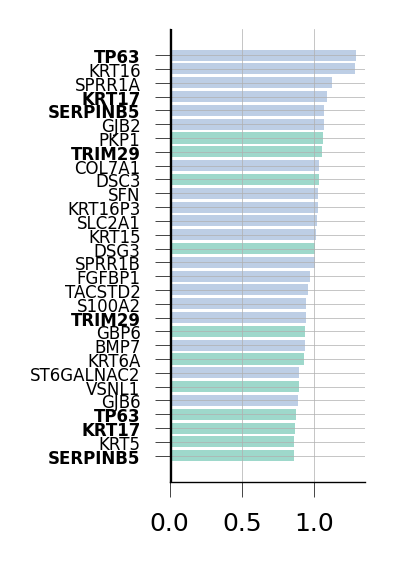

In [65]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(1.2, 1.77))
plot_modality_loadings(mofa_loadings.reset_index().nlargest(30, FACTOR), score=FACTOR, feature="genes", modality_column="modality", palette=palette, ax=axm[0], xlabel="MOFA+ loading", legend=False, fontsize=4)
plt.xticks([0, 0.5, 1.0])
plt.xlabel(None)

fig.savefig(f"../data/plots/mofa_loadings_factor-{FACTOR}.png", transparent=True, dpi=600, bbox_inches="tight")


/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_39393/3402367377.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  factor = mofa_loadings.reset_index().pivot_table(index="genes", columns="modality", values=idx)


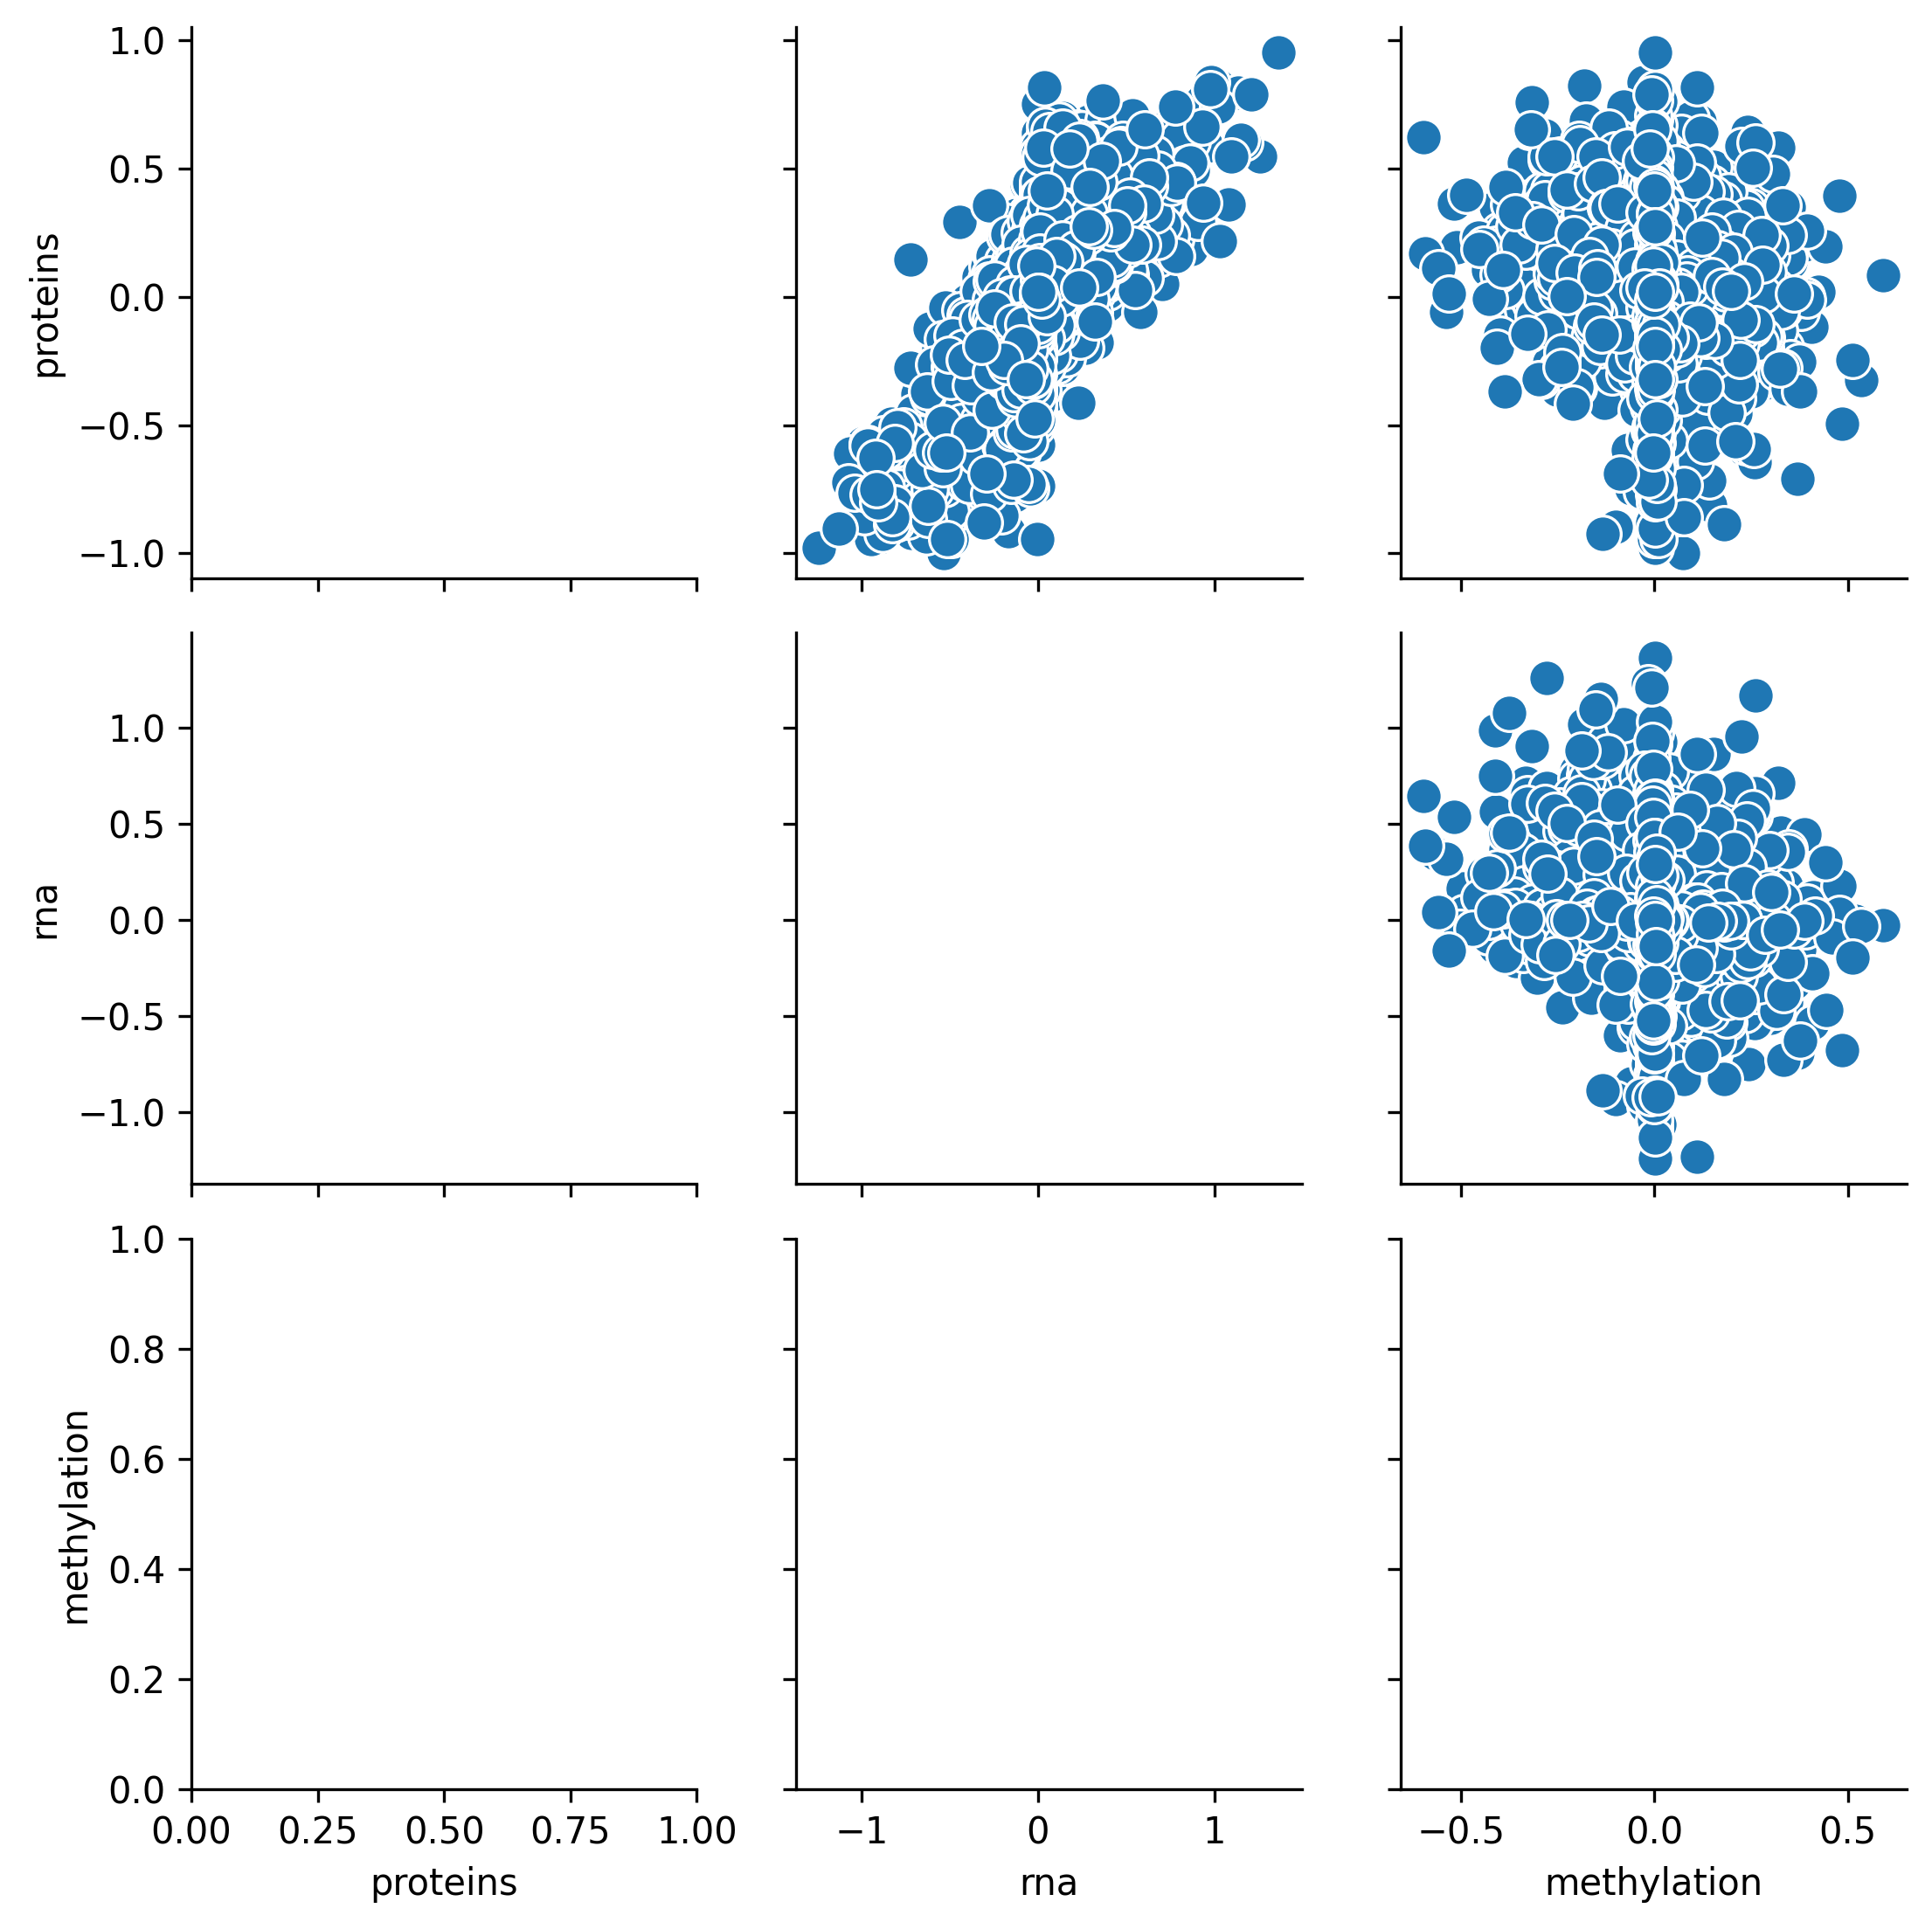

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_39393/3402367377.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  factor = mofa_loadings.reset_index().pivot_table(index="genes", columns="modality", values=idx)


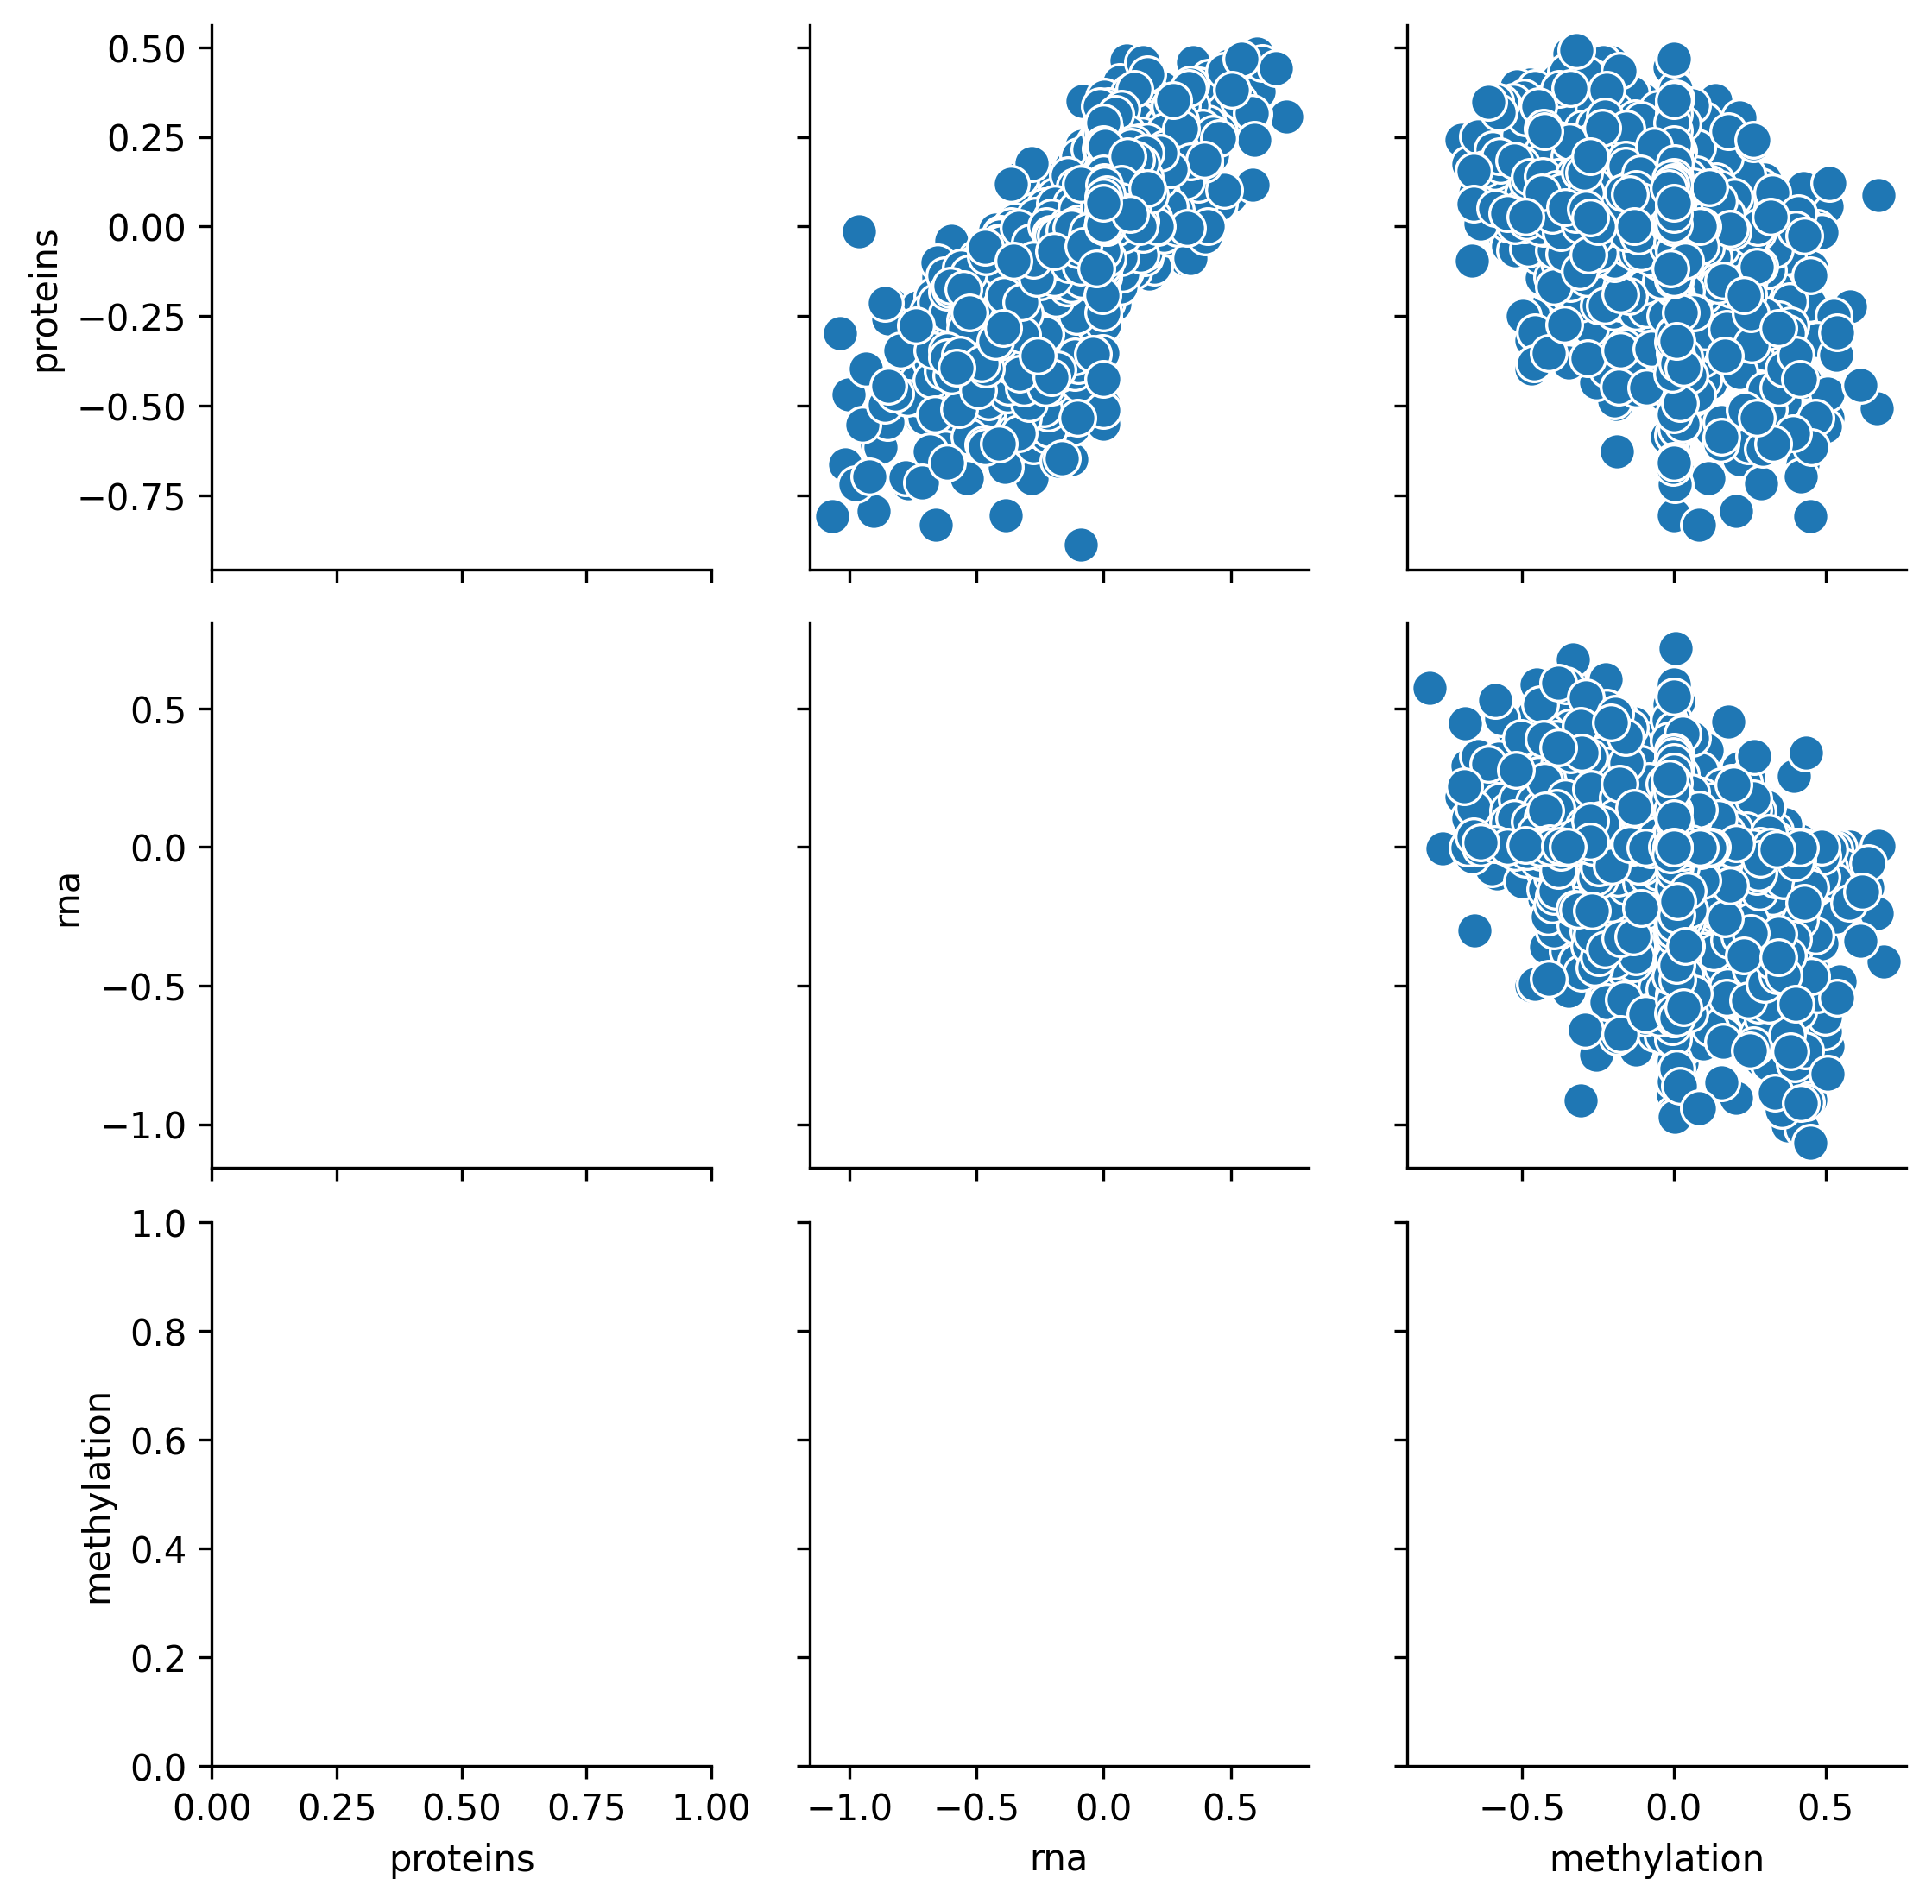

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_39393/3402367377.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  factor = mofa_loadings.reset_index().pivot_table(index="genes", columns="modality", values=idx)


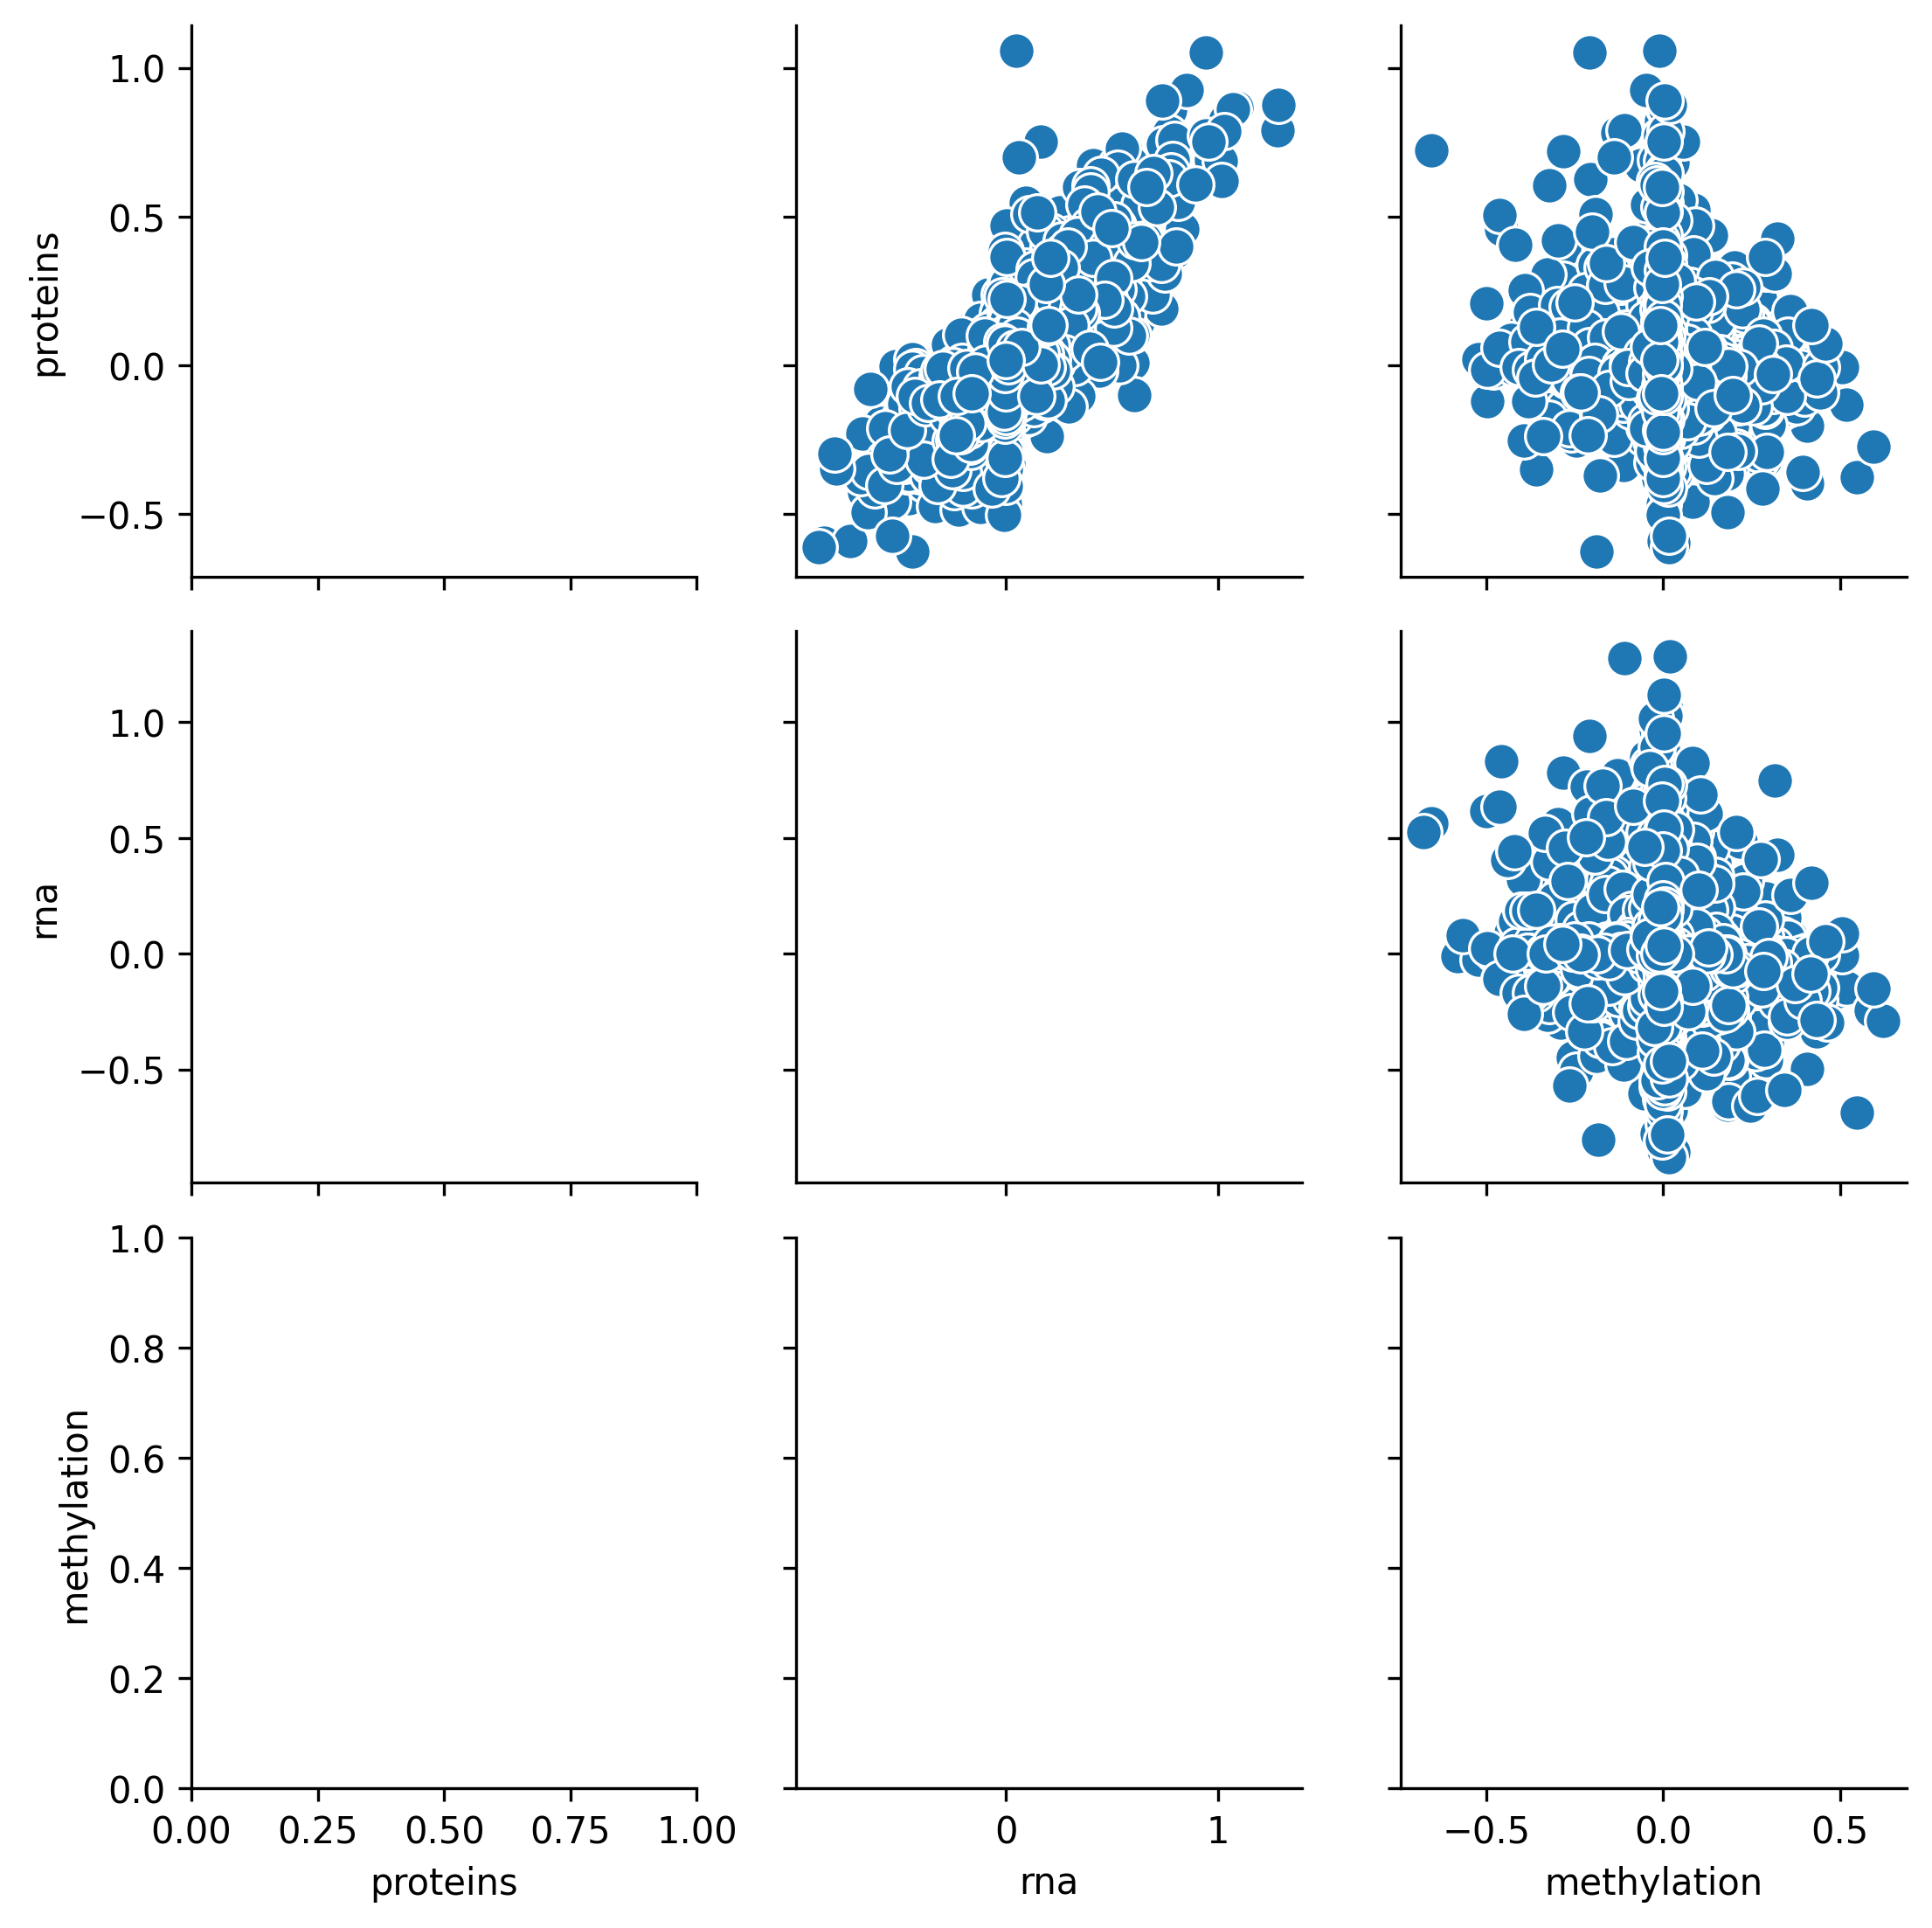

In [34]:
for idx in range(3):
    factor = mofa_loadings.reset_index().pivot_table(index="genes", columns="modality", values=idx)

    g = sns.PairGrid(factor, x_vars=["methylation", "rna", "proteins"][::-1], y_vars=["methylation", "rna", "proteins"][::-1])
    g.map_upper(sns.scatterplot)
    plt.show()